In [7]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


# NSL-KDD Dataset: Comprehensive Guide

## Dataset Overview

### What is the NSL-KDD Dataset?
full form is Network State Long-Run Knowledge Discovery Dataset (often referred to in literature simply as the NSL-KDD dataset or Network Security Laboratory Knowledge Discovery dataset).
NSL-KDD is a benchmark dataset for network intrusion detection. It's an improved version of the original KDD Cup 1999 dataset, which was created by MIT Lincoln Labs for the DARPA Intrusion Detection Evaluation Program.

### Why NSL-KDD?
- **Standard Benchmark**: Most widely used dataset for IDS research
- **Labeled Data**: Every connection is tagged as normal or specific attack type
- **Realistic**: Simulates real network traffic with various attack scenarios
- **Manageable Size**: Perfect for learning and prototyping
- **Comparable Results**: Allows benchmarking against other studies

### Where is it Used?
- **Academic Research**: 1000+ papers use this dataset
- **Industry**: Baseline testing for commercial IDS products
- **Competitions**: Used in Kaggle competitions
- **Education**: Most universities use it to teach network security

### How it Relates to Our Project
We're building an AI-powered Intrusion Detection System. The NSL-KDD dataset provides the ground truth data needed to:
1. Train our model to recognize attack patterns
2. Test our model's accuracy
3. Compare our performance with industry standards
4. Understand what network features indicate attacks

### What Does the Data Represent?
Each row represents a single network connection (or session). The features describe various aspects of that connection, and the label tells us if it was normal or an attack.

---

## Column Explanations

**Total**: 41 Features + 1 Label + 1 Difficulty Score

### Basic Features (Individual TCP Connections)

| # | Feature | Description | Significance |
|---|---------|-------------|--------------|
| 1 | **duration** | Length of connection (seconds) | High duration might indicate suspicious activity |
| 2 | **protocol_type** | Network protocol used (tcp, udp, icmp) | Different protocols have different attack patterns |
| 3 | **service** | Network service on destination (http, ftp, smtp, ssh) | Certain services are more vulnerable to attacks |
| 4 | **flag** | Status of the connection (SF, S0, REJ) | Indicates connection state and success/failure |
| 5 | **src_bytes** | Data bytes from source to destination | Very high values might indicate data exfiltration |
| 6 | **dst_bytes** | Data bytes from destination to source | Asymmetric bytes often indicate different behavior |
| 7 | **land** | If source and destination IPs are same (1) or different (0) | Land attack detection (should be rare) |

### Content Features (Inside the Connection)

| # | Feature | Description | Significance |
|---|---------|-------------|--------------|
| 8 | **wrong_fragment** | Number of wrong fragments | Fragmentation attacks often increase this |
| 9 | **urgent** | Number of urgent packets | Unusually high urgent packets may indicate attacks |
| 10 | **hot** | Number of "hot" indicators | System-level suspicious activities |
| 11 | **num_failed_logins** | Failed login attempts | High values = brute force attempts |
| 12 | **logged_in** | Successfully logged in (1) or not (0) | Normal behavior vs unauthorized access |
| 13 | **num_compromised** | Number of compromised conditions | System compromise indicators |
| 14 | **root_shell** | Root shell obtained (1) or not (0) | Critical privilege escalation indicator |
| 15 | **su_attempted** | "su" command attempted (1) or not (0) | Attempts to gain root access |
| 16 | **num_root** | Number of root accesses | Unauthorized root access attempts |
| 17 | **num_file_creations** | Number of file creation operations | Malware often creates files |
| 18 | **num_shells** | Number of shell prompts | Remote shell access attempts |
| 19 | **num_access_files** | Number of access to files | File access patterns |
| 20 | **num_outbound_cmds** | Number of outbound commands | Rare in normal traffic, indicates compromise |
| 21 | **is_host_login** | If login is on host (1) or not (0) | User authentication patterns |
| 22 | **is_guest_login** | Guest login (1) or not (0) | Guest accounts are often exploited |

### Time-Based Traffic Features (2-second Window)

| # | Feature | Description | Significance |
|---|---------|-------------|--------------|
| 23 | **count** | Number of connections to same host in past 2 seconds | Rapid connections = scanning/attack |
| 24 | **srv_count** | Number of connections to same service in past 2 seconds | Service-specific attacks |
| 25 | **serror_rate** | % of connections with SYN errors | Connection attempts failures |
| 26 | **srv_serror_rate** | % of connections to same service with SYN errors | Service-specific issues |
| 27 | **rerror_rate** | % of connections with REJ errors | Rejected connections |
| 28 | **srv_rerror_rate** | % of connections to same service with REJ errors | Service-specific rejections |
| 29 | **same_srv_rate** | % of connections to same service | Consistent service usage patterns |
| 30 | **diff_srv_rate** | % of connections to different services | Unusual service variety = scanning |
| 31 | **srv_diff_host_rate** | % of connections to different hosts | Unusual host variety = scanning |

### Host-Based Traffic Features (100-connection Window)

| # | Feature | Description | Significance |
|---|---------|-------------|--------------|
| 32 | **dst_host_count** | Count of connections to same destination host | Host targeting patterns |
| 33 | **dst_host_srv_count** | Count of connections to same service on destination host | Service targeting |
| 34 | **dst_host_same_srv_rate** | % of connections to same service on destination host | Service consistency |
| 35 | **dst_host_diff_srv_rate** | % of connections to different services on destination host | Service diversity = scanning |
| 36 | **dst_host_same_src_port_rate** | % of connections from same source port | Source port consistency |
| 37 | **dst_host_srv_diff_host_rate** | % of connections to different hosts with same service | Service-based targeting |
| 38 | **dst_host_serror_rate** | % of connections with SYN errors to destination | Failed connections |
| 39 | **dst_host_srv_serror_rate** | % of connections to same service with SYN errors | Service-specific failures |
| 40 | **dst_host_rerror_rate** | % of connections with REJ errors to destination | Rejected connections |
| 41 | **dst_host_srv_rerror_rate** | % of connections to same service with REJ errors | Service-specific rejections |

### Label (Target Variable)

| # | Feature | Description |
|---|---------|-------------|
| 42 | **label** | Type of connection: 'normal' or attack type |
| 43 | **difficulty** | Complexity score of detection (not used in our project) |

---

## Attack Types Explained

### 1. DoS (Denial of Service)
- **Examples**: back, land, neptune, pod, smurf, teardrop
- **Goal**: Make service unavailable to legitimate users
- **Pattern**: High volume, many connections

### 2. Probing
- **Examples**: ipsweep, nmap, portsweep, satan
- **Goal**: Gather information about network
- **Pattern**: Unusual port/service combinations

### 3. R2L (Remote to Local)
- **Examples**: ftp_write, guess_passwd, imap, multihop, spy, warezclient, warezmaster
- **Goal**: Gain unauthorized access to local system
- **Pattern**: Authentication attempts, file operations

### 4. U2R (User to Root)
- **Examples**: buffer_overflow, loadmodule, perl, rootkit
- **Goal**: Gain root/administrator privileges
- **Pattern**: Privilege escalation attempts

---

## Why These Features Matter for Our AI Model

1. **Network Behavior**: Features capture normal vs malicious patterns
2. **Temporal Patterns**: Time-based features detect scanning/attacks
3. **Statistical Patterns**: Rate-based features identify anomalies
4. **Protocol Knowledge**: Features reflect network protocol characteristics
5. **Behavioral Signatures**: Different attacks leave different footprints

In [8]:
# Cell 2: Load the CSV files
# Since you converted to CSV, loading should be straightforward

# Define column names (NSL-KDD has 42 features + 1 label + 1 difficulty)
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

# Load the data
train_df = pd.read_csv('/home/vboxuser/WORK/AI AND ML/PyCharmMiscProject/Projects/ai_network_ids/data/test.csv', header=None, names=columns)
test_df = pd.read_csv('/home/vboxuser/WORK/AI AND ML/PyCharmMiscProject/Projects/ai_network_ids/data/test.csv', header=None, names=columns)

print(f"Training data loaded: {train_df.shape[0]:,} rows, {train_df.shape[1]} columns")
print(f"Test data loaded: {test_df.shape[0]:,} rows, {test_df.shape[1]} columns")

# Combine for full analysis
df = pd.concat([train_df, test_df], ignore_index=True)
print(f"Combined dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Display first few rows
df.head()

Training data loaded: 22,544 rows, 43 columns
Test data loaded: 22,544 rows, 43 columns
Combined dataset: 45,088 rows, 43 columns


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,229,10,0.0,0.00,1.0,1.0,0.04,0.06,0.00,255,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,136,1,0.0,0.00,1.0,1.0,0.01,0.06,0.00,255,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0.0,0.00,0.0,0.0,1.00,0.00,0.00,134,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,65,0.0,0.00,0.0,0.0,1.00,0.00,1.00,3,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,8,0.0,0.12,1.0,0.5,1.00,0.00,0.75,29,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [9]:
# Cell 3: Dataset Overview

print("="*80)
print("DATASET OVERVIEW")
print("="*80)

# Basic info
print("\nData Types:")
print(df.dtypes.value_counts())

print("\nMemory Usage:")
print(f"{df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\nMissing Values:")
missing_values = df.isnull().sum()
if missing_values.sum() == 0:
    print("No missing values found!")
else:
    print(missing_values[missing_values > 0])

print("\nStatistical Summary (Numerical Features):")
df.describe().T

print("\nStatistical Summary (Categorical Features):")
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head())

DATASET OVERVIEW

Data Types:
int64      24
float64    15
object      4
Name: count, dtype: int64

Memory Usage:
23.98 MB

Missing Values:
No missing values found!

Statistical Summary (Numerical Features):

Statistical Summary (Categorical Features):

protocol_type:
protocol_type
tcp     37760
udp      5242
icmp     2086
Name: count, dtype: int64

service:
service
http       15706
private     9548
telnet      3252
pop_3       2038
smtp        1868
Name: count, dtype: int64

flag:
flag
SF      29750
REJ      7700
S0       4026
RSTO     1546
RSTR     1338
Name: count, dtype: int64

label:
label
normal          19422
neptune          9314
guess_passwd     2462
mscan            1992
warezmaster      1888
Name: count, dtype: int64


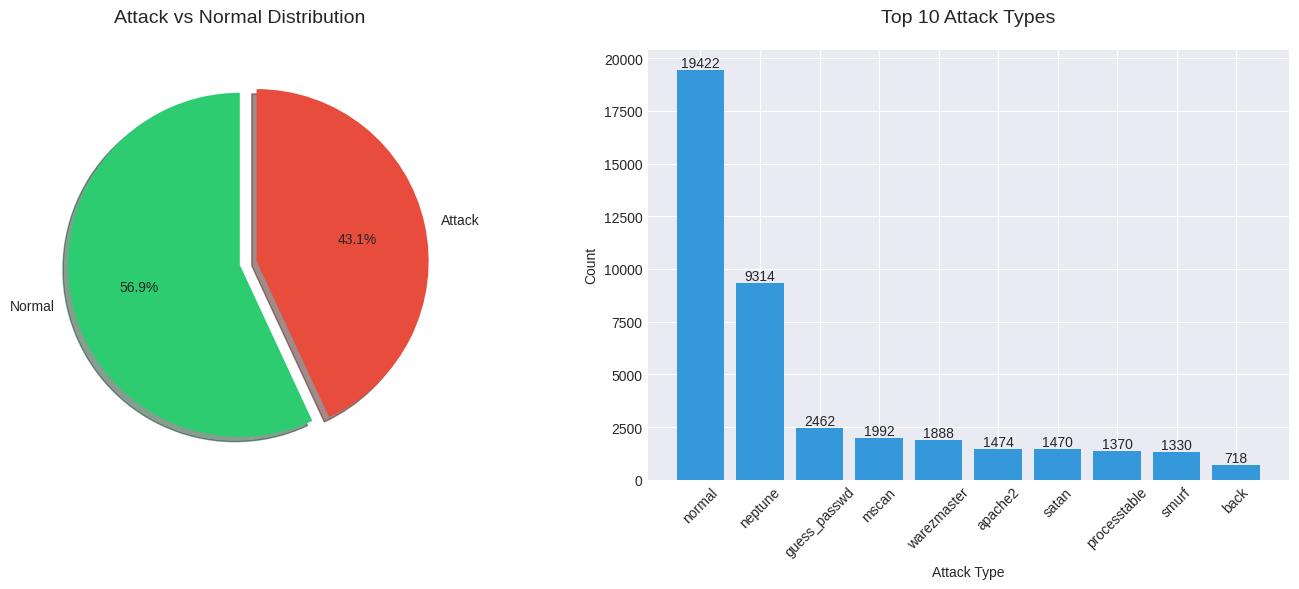

CLASS DISTRIBUTION STATISTICS
Total samples: 45,088
Normal samples: 19,422 (43.08%)
Attack samples: 25,666 (56.92%)

Imbalance Ratio: 0.76:1


In [10]:
# Cell 4: Target Variable Analysis (Matplotlib/Seaborn Version)

import matplotlib.pyplot as plt
import seaborn as sns

# Create binary target (Normal vs Attack)
df['attack'] = df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Pie chart for binary classification
attack_counts = df['attack'].value_counts()
colors = ['#2ecc71', '#e74c3c']
explode = (0, 0.1)
axes[0].pie(attack_counts.values, 
            labels=['Normal', 'Attack'],
            autopct='%1.1f%%',
            colors=colors,
            explode=explode,
            shadow=True,
            startangle=90)
axes[0].set_title('Attack vs Normal Distribution', fontsize=14, pad=20)

# 2. Bar chart for attack types
attack_types = df['label'].value_counts().head(10)
bars = axes[1].bar(attack_types.index, attack_types.values, color='#3498db')
axes[1].set_title('Top 10 Attack Types', fontsize=14, pad=20)
axes[1].set_xlabel('Attack Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print statistics
print("="*80)
print("CLASS DISTRIBUTION STATISTICS")
print("="*80)
total = len(df)
print(f"Total samples: {total:,}")
print(f"Normal samples: {sum(df['attack'] == 0):,} ({sum(df['attack'] == 0)/total*100:.2f}%)")
print(f"Attack samples: {sum(df['attack'] == 1):,} ({sum(df['attack'] == 1)/total*100:.2f}%)")
print(f"\nImbalance Ratio: {sum(df['attack'] == 0)/sum(df['attack'] == 1):.2f}:1")

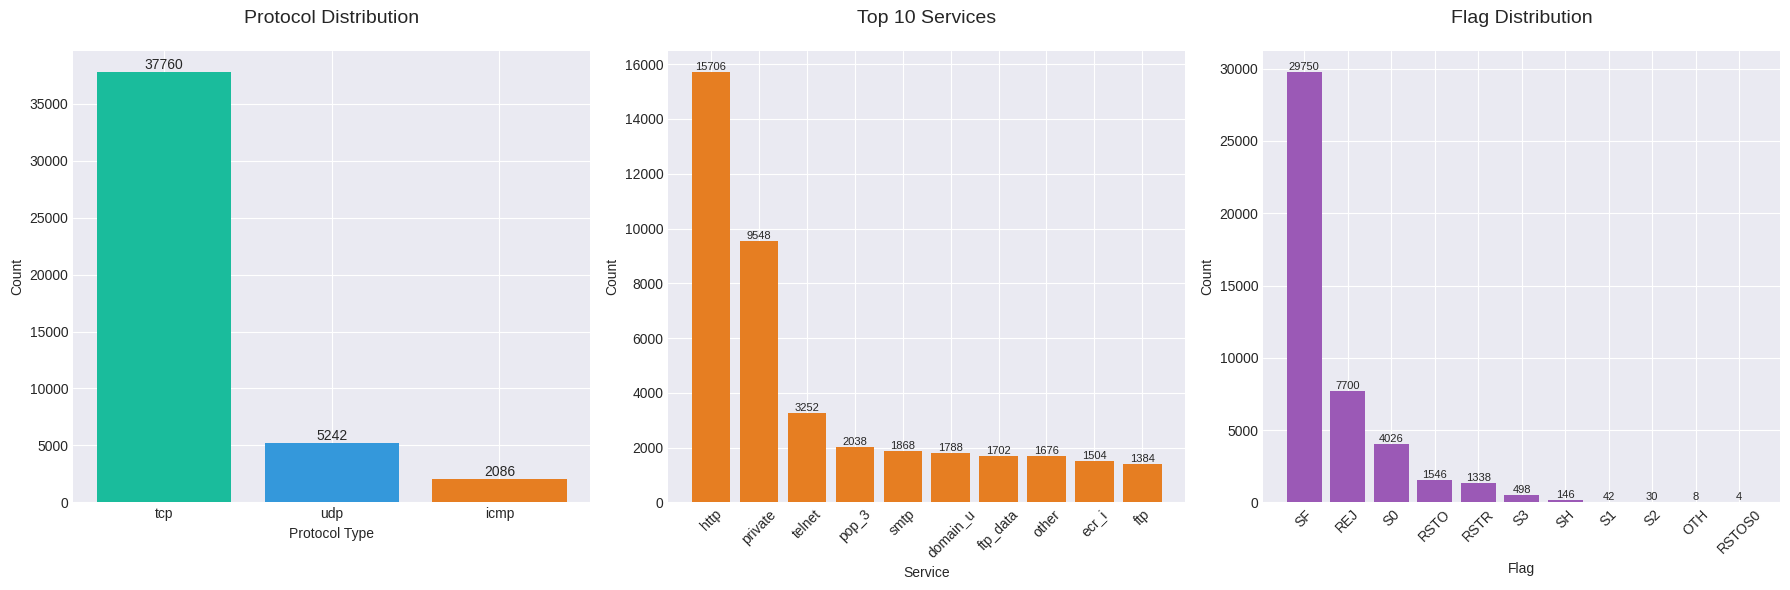

PROTOCOL & SERVICE INSIGHTS

Dominant Protocol: tcp (83.7%)
Most Common Service: http (34.8%)
Most Common Flag: SF (66.0%)


In [11]:
# Cell 5: Protocol and Service Analysis (Matplotlib Version)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Protocol distribution
protocol_counts = df['protocol_type'].value_counts()
bars1 = axes[0].bar(protocol_counts.index, protocol_counts.values, 
                    color=['#1abc9c', '#3498db', '#e67e22'])
axes[0].set_title('Protocol Distribution', fontsize=14, pad=20)
axes[0].set_xlabel('Protocol Type')
axes[0].set_ylabel('Count')

for bar in bars1:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

# 2. Service distribution (top 10)
service_counts = df['service'].value_counts().head(10)
bars2 = axes[1].bar(service_counts.index, service_counts.values, color='#e67e22')
axes[1].set_title('Top 10 Services', fontsize=14, pad=20)
axes[1].set_xlabel('Service')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

for bar in bars2:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=8)

# 3. Flag distribution
flag_counts = df['flag'].value_counts()
bars3 = axes[2].bar(flag_counts.index, flag_counts.values, color='#9b59b6')
axes[2].set_title('Flag Distribution', fontsize=14, pad=20)
axes[2].set_xlabel('Flag')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

for bar in bars3:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Print insights
print("="*80)
print("PROTOCOL & SERVICE INSIGHTS")
print("="*80)
print(f"\nDominant Protocol: {protocol_counts.index[0]} ({protocol_counts.iloc[0]/len(df)*100:.1f}%)")
print(f"Most Common Service: {service_counts.index[0]} ({service_counts.iloc[0]/len(df)*100:.1f}%)")
print(f"Most Common Flag: {flag_counts.index[0]} ({flag_counts.iloc[0]/len(df)*100:.1f}%)")

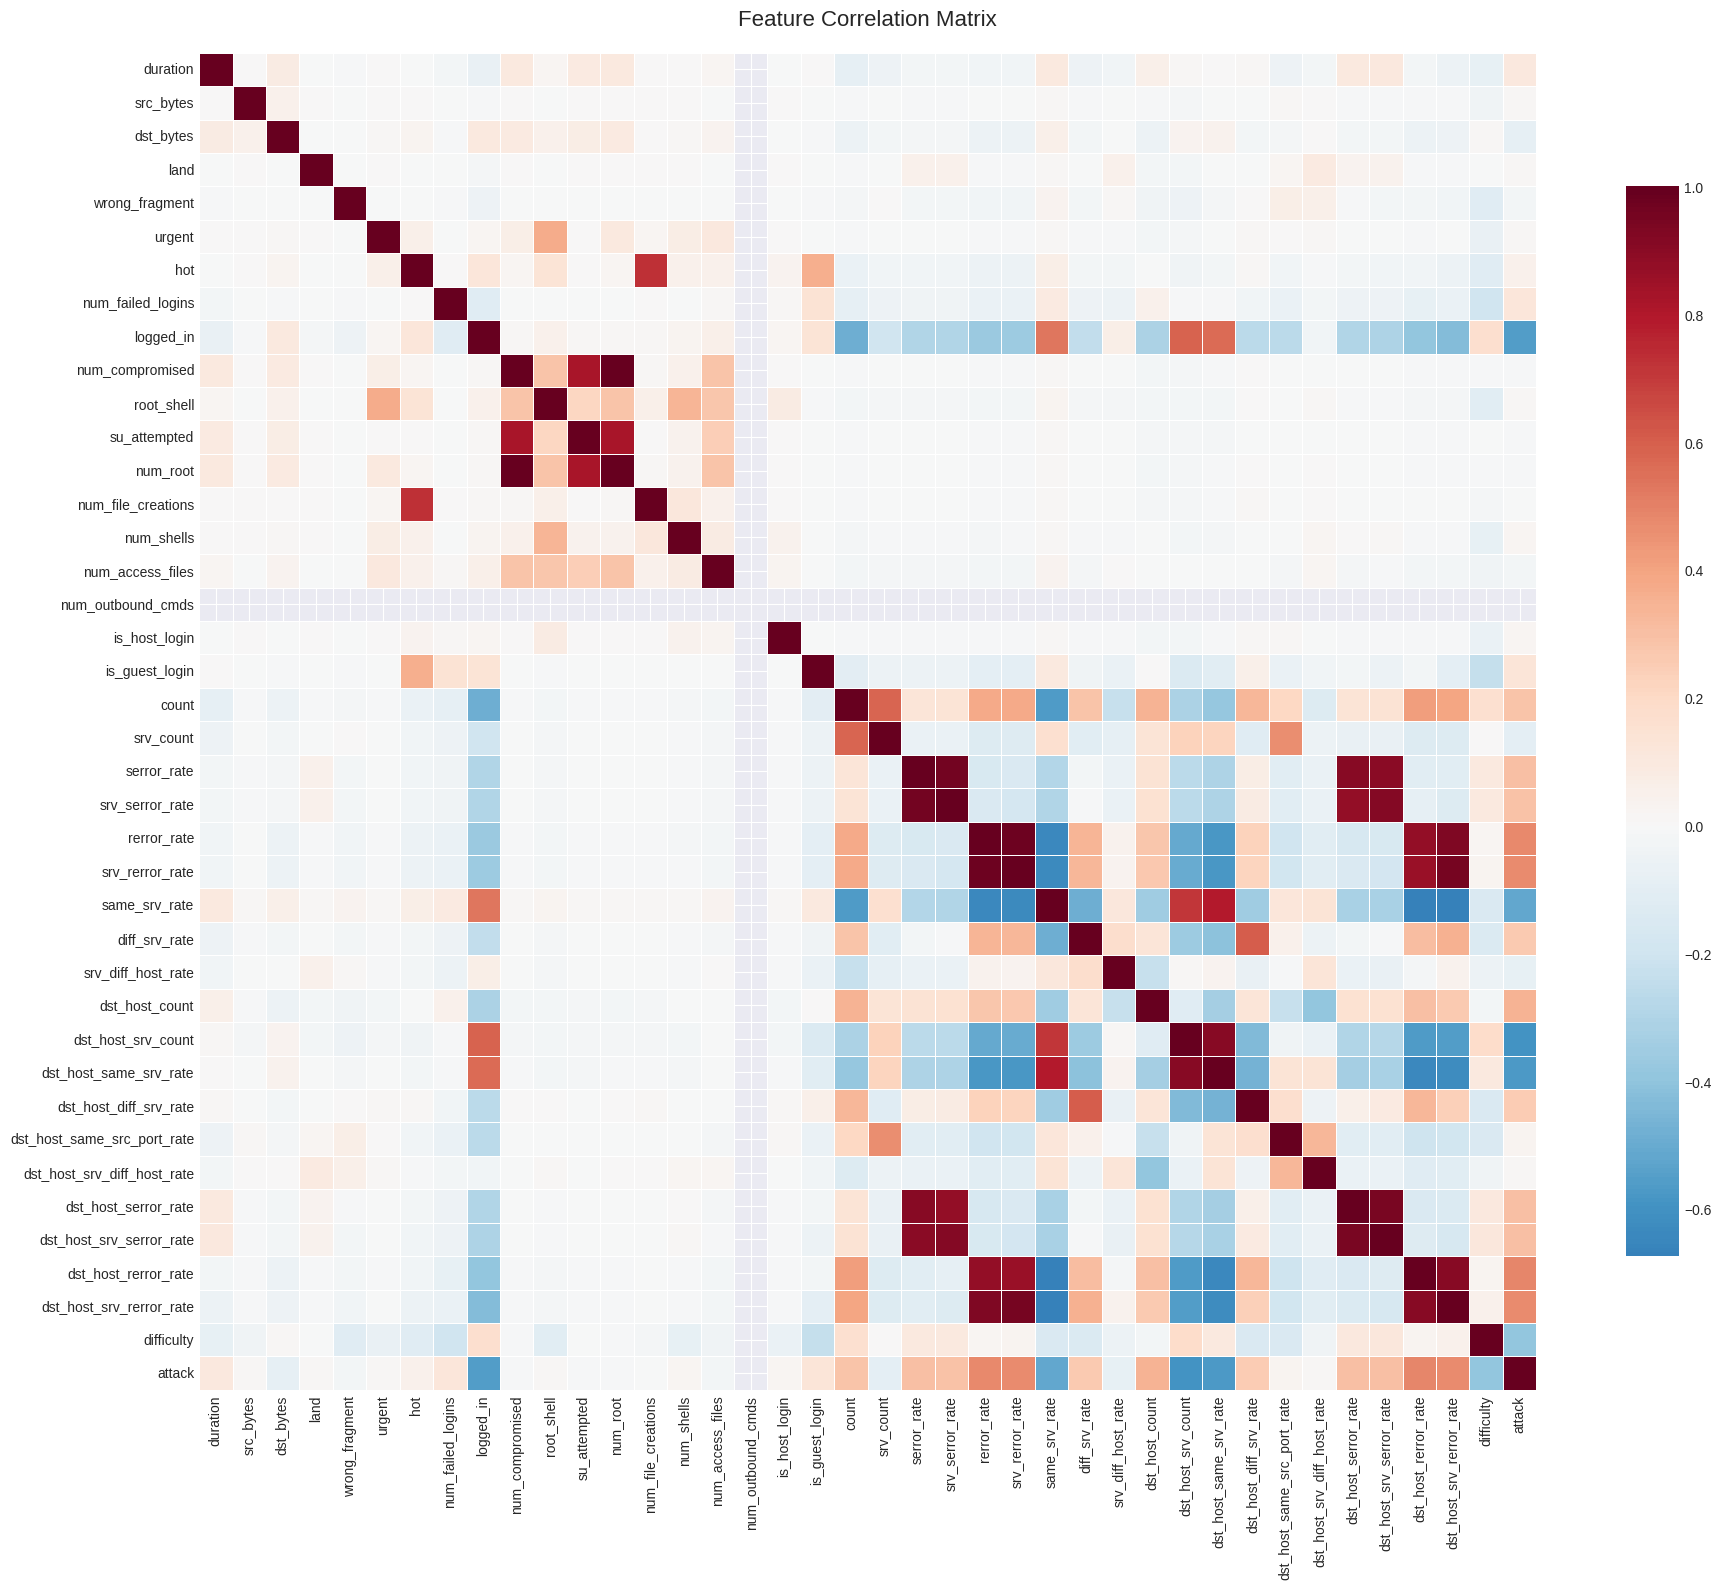

TOP 10 FEATURES CORRELATED WITH ATTACK
dst_host_rerror_rate: 0.4882
rerror_rate         : 0.4811
srv_rerror_rate     : 0.4745
dst_host_srv_rerror_rate: 0.4726
dst_host_count      : 0.3518
dst_host_srv_serror_rate: 0.3003
dst_host_serror_rate: 0.2988
serror_rate         : 0.2938
srv_serror_rate     : 0.2931
count               : 0.2812


In [12]:
# Cell 6: Correlation Analysis

# Select only numerical features for correlation
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

# Plot correlation matrix with attacks
plt.figure(figsize=(20, 16))
sns.heatmap(
    correlation_matrix,
    cmap='RdBu_r',
    center=0,
    annot=False,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

# Top correlated features with attack
print("="*80)
print("TOP 10 FEATURES CORRELATED WITH ATTACK")
print("="*80)
attack_corr = correlation_matrix['attack'].sort_values(ascending=False)
for feature, corr in attack_corr[1:11].items():
    print(f"{feature:20s}: {corr:.4f}")

Distribution of Labels in Training Set:
label
normal             9711
neptune            4657
guess_passwd       1231
mscan               996
warezmaster         944
apache2             737
satan               735
processtable        685
smurf               665
back                359
snmpguess           331
saint               319
mailbomb            293
snmpgetattack       178
portsweep           157
ipsweep             141
httptunnel          133
nmap                 73
pod                  41
buffer_overflow      20
multihop             18
named                17
ps                   15
sendmail             14
rootkit              13
xterm                13
teardrop             12
xlock                 9
land                  7
xsnoop                4
ftp_write             3
worm                  2
loadmodule            2
perl                  2
sqlattack             2
udpstorm              2
phf                   2
imap                  1
Name: count, dtype: int64

Distribution of

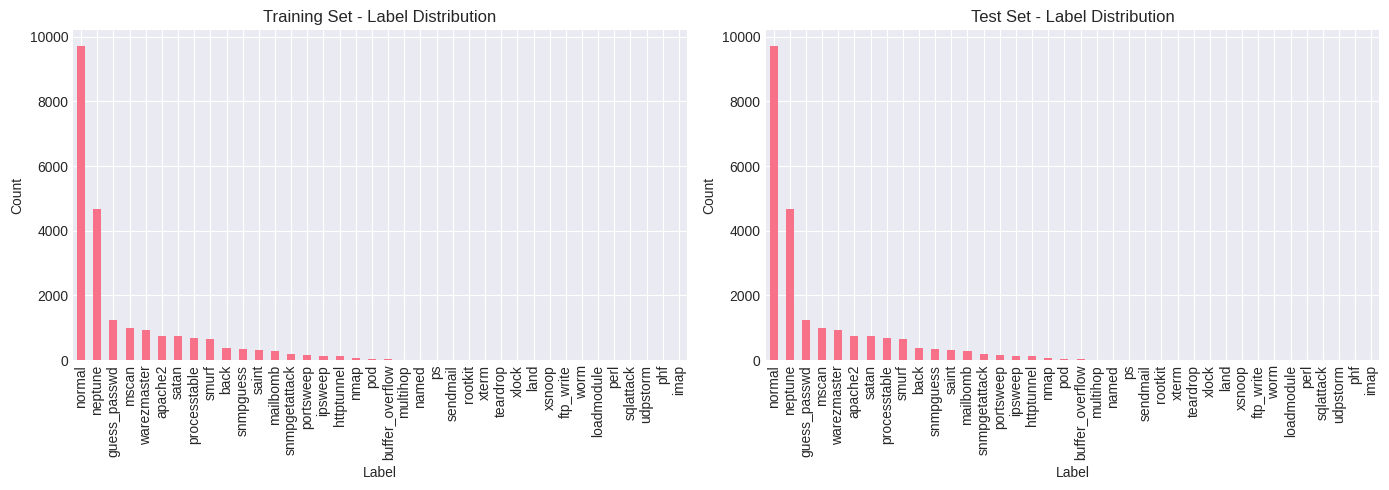

In [13]:
# Cell 7: Target Variable Distribution
print("Distribution of Labels in Training Set:")
print(train_df['label'].value_counts())

print("\nDistribution of Labels in Test Set:")
print(test_df['label'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
train_df['label'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Training Set - Label Distribution')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')

# Test set
test_df['label'].value_counts().plot(kind='bar', ax=axes[1])
axes[1].set_title('Test Set - Label Distribution')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Training Set - Binary Classification Distribution:
Normal: 43.08% (9711 samples)
Attack: 56.92% (12833 samples)

Test Set - Binary Classification Distribution:
Normal: 43.08% (9711 samples)
Attack: 56.92% (12833 samples)


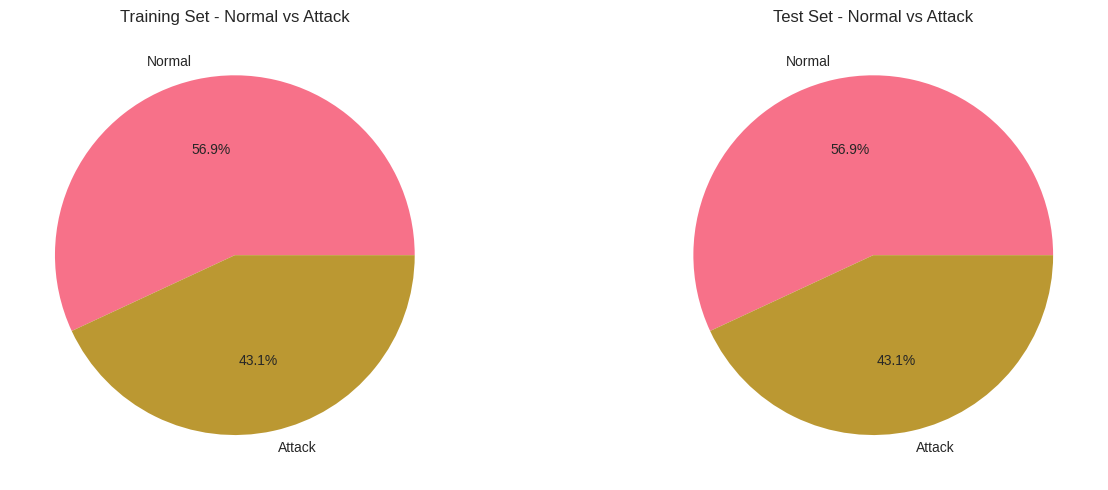

In [14]:
# Cell 8: Normal vs Attack Distribution
# Create binary classification column
train_df['attack'] = train_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
test_df['attack'] = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Calculate percentages
train_normal_pct = (train_df['attack'] == 0).mean() * 100
train_attack_pct = (train_df['attack'] == 1).mean() * 100

test_normal_pct = (test_df['attack'] == 0).mean() * 100
test_attack_pct = (test_df['attack'] == 1).mean() * 100

print("Training Set - Binary Classification Distribution:")
print(f"Normal: {train_normal_pct:.2f}% ({sum(train_df['attack'] == 0)} samples)")
print(f"Attack: {train_attack_pct:.2f}% ({sum(train_df['attack'] == 1)} samples)")

print("\nTest Set - Binary Classification Distribution:")
print(f"Normal: {test_normal_pct:.2f}% ({sum(test_df['attack'] == 0)} samples)")
print(f"Attack: {test_attack_pct:.2f}% ({sum(test_df['attack'] == 1)} samples)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
train_df['attack'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0], 
                                        labels=['Normal', 'Attack'])
axes[0].set_title('Training Set - Normal vs Attack')
axes[0].set_ylabel('')

# Test set
test_df['attack'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1],
                                        labels=['Normal', 'Attack'])
axes[1].set_title('Test Set - Normal vs Attack')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Training Set - Attack Categories:
attack_category
DoS        5741
Other      3752
R2L        2197
Probing    1106
U2R          37
Name: count, dtype: int64

Test Set - Attack Categories:
attack_category
DoS        5741
Other      3752
R2L        2197
Probing    1106
U2R          37
Name: count, dtype: int64


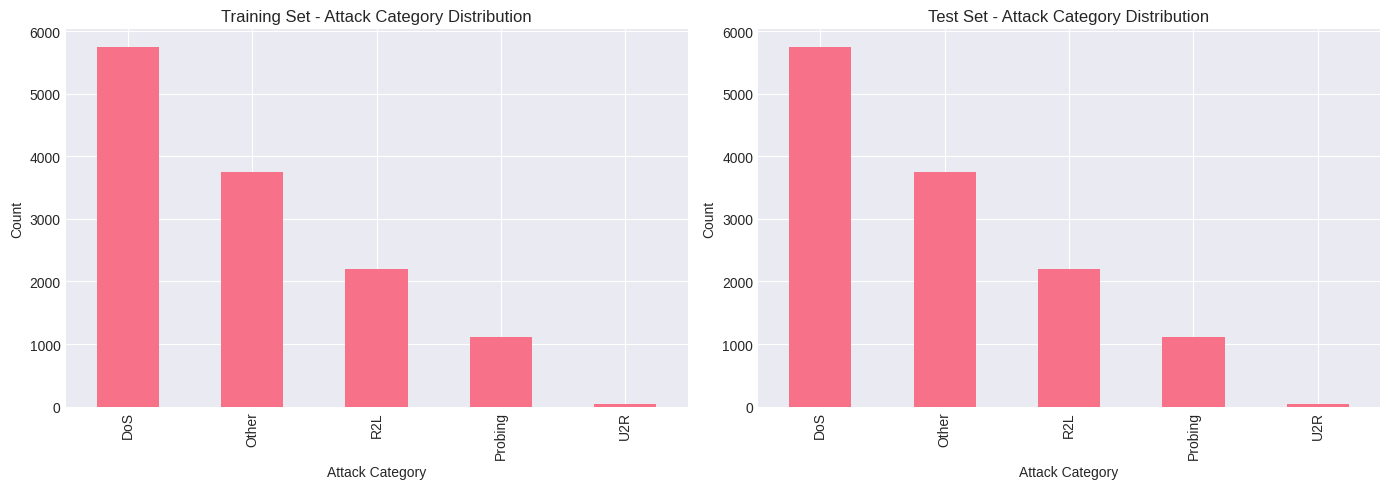

In [15]:
# Cell 9: Attack Type Distribution
# Extract attack types (remove 'normal')
attack_types_train = train_df[train_df['label'] != 'normal']['label'].value_counts()
attack_types_test = test_df[test_df['label'] != 'normal']['label'].value_counts()

# Categorize attacks
def categorize_attack(label):
    dos_attacks = ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop']
    probing_attacks = ['ipsweep', 'nmap', 'portsweep', 'satan']
    r2l_attacks = ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'spy', 
                   'warezclient', 'warezmaster']
    u2r_attacks = ['buffer_overflow', 'loadmodule', 'perl', 'rootkit']
    
    if label in dos_attacks:
        return 'DoS'
    elif label in probing_attacks:
        return 'Probing'
    elif label in r2l_attacks:
        return 'R2L'
    elif label in u2r_attacks:
        return 'U2R'
    else:
        return 'Other'

train_df['attack_category'] = train_df['label'].apply(categorize_attack)
test_df['attack_category'] = test_df['label'].apply(categorize_attack)

print("Training Set - Attack Categories:")
print(train_df[train_df['label'] != 'normal']['attack_category'].value_counts())

print("\nTest Set - Attack Categories:")
print(test_df[test_df['label'] != 'normal']['attack_category'].value_counts())

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
attack_counts_train = train_df[train_df['label'] != 'normal']['attack_category'].value_counts()
attack_counts_train.plot(kind='bar', ax=axes[0])
axes[0].set_title('Training Set - Attack Category Distribution')
axes[0].set_xlabel('Attack Category')
axes[0].set_ylabel('Count')

# Test set
attack_counts_test = test_df[test_df['label'] != 'normal']['attack_category'].value_counts()
attack_counts_test.plot(kind='bar', ax=axes[1])
axes[1].set_title('Test Set - Attack Category Distribution')
axes[1].set_xlabel('Attack Category')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

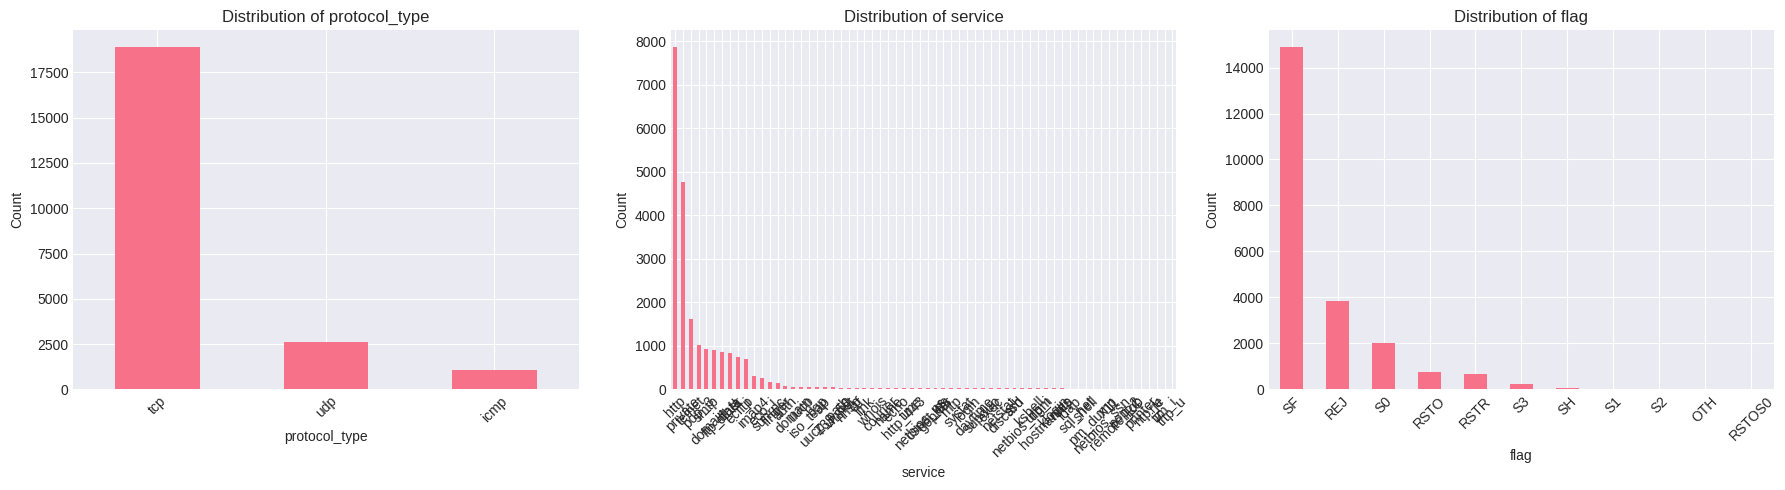


protocol_type distribution:
protocol_type
tcp     18880
udp      2621
icmp     1043
Name: count, dtype: int64

service distribution:
service
http           7853
private        4774
telnet         1626
pop_3          1019
smtp            934
domain_u        894
ftp_data        851
other           838
ecr_i           752
ftp             692
imap4           306
eco_i           262
sunrpc          159
finger          136
auth             67
domain           51
uucp             50
iso_tsap         48
bgp              46
uucp_path        46
Z39_50           45
vmnet            43
nnsp             42
ctf              41
link             41
whois            40
courier          40
name             37
echo             37
http_443         36
time             36
netbios_ns       36
csnet_ns         34
gopher           34
efs              33
mtp              32
systat           32
login            29
daytime          28
supdup           27
exec             27
netstat          26
discard          2

In [16]:
# Cell 10: Categorical Features Analysis
categorical_cols = ['protocol_type', 'service', 'flag']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(categorical_cols):
    train_df[col].value_counts().plot(kind='bar', ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print value counts
for col in categorical_cols:
    print(f"\n{col} distribution:")
    print(train_df[col].value_counts())

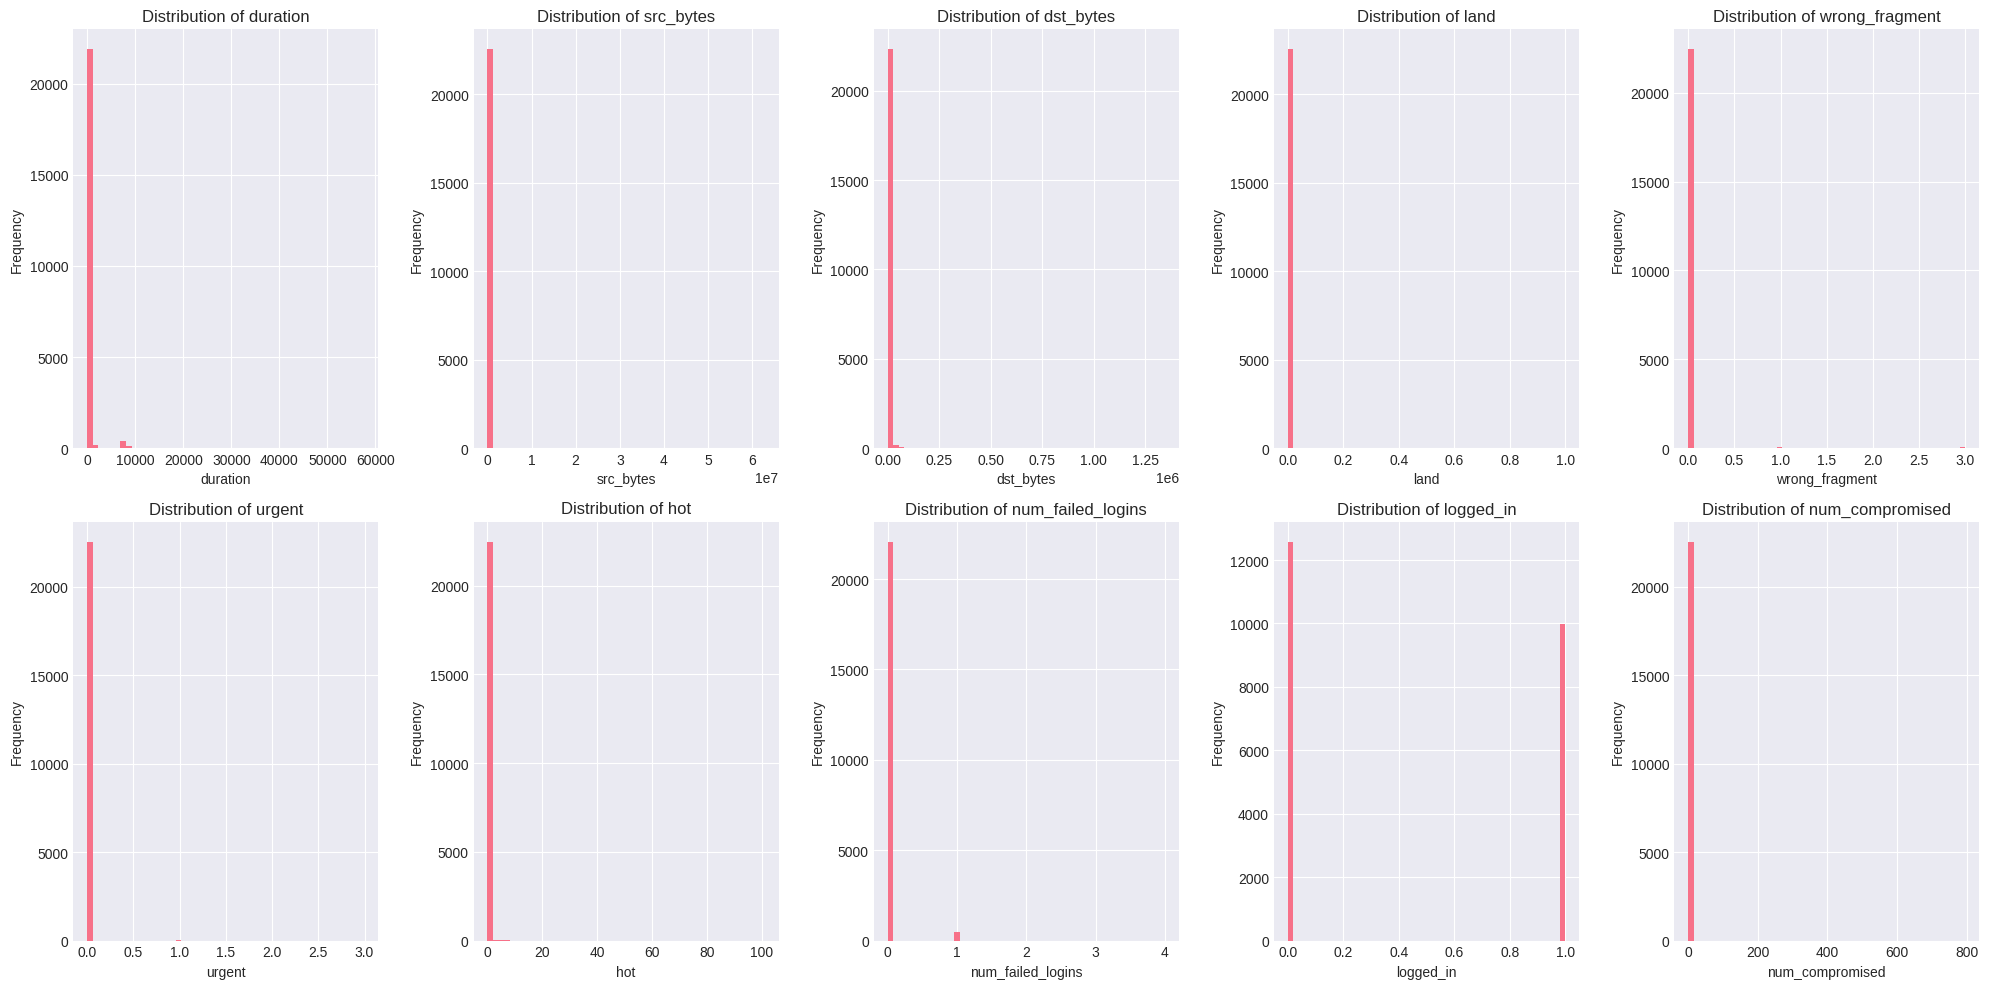

In [17]:
# Cell 11: Numerical Features Distribution (First 10 features)
numerical_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in ['label', 'difficulty', 'attack']]

# Plot distributions for first 10 numerical features
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols[:10]):
    train_df[col].hist(bins=50, ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

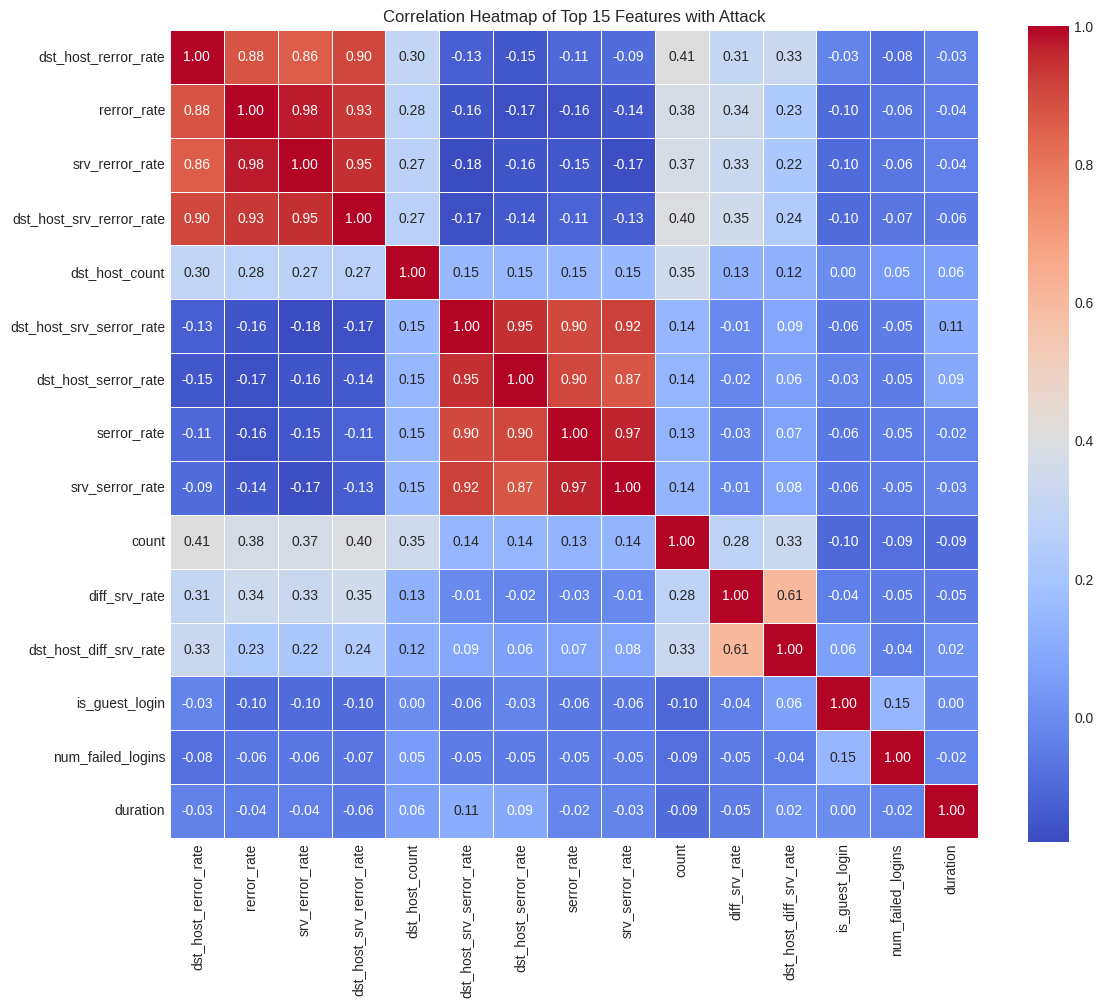

In [18]:
# Cell 12: Correlation Heatmap (Top 15 features)
# Select top features with highest correlation to 'attack'
correlations = train_df[numerical_cols + ['attack']].corr()['attack'].sort_values(ascending=False)
top_features = correlations.index[1:16]  # Exclude 'attack' itself

plt.figure(figsize=(12, 10))
correlation_matrix = train_df[top_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Top 15 Features with Attack')
plt.tight_layout()
plt.show()

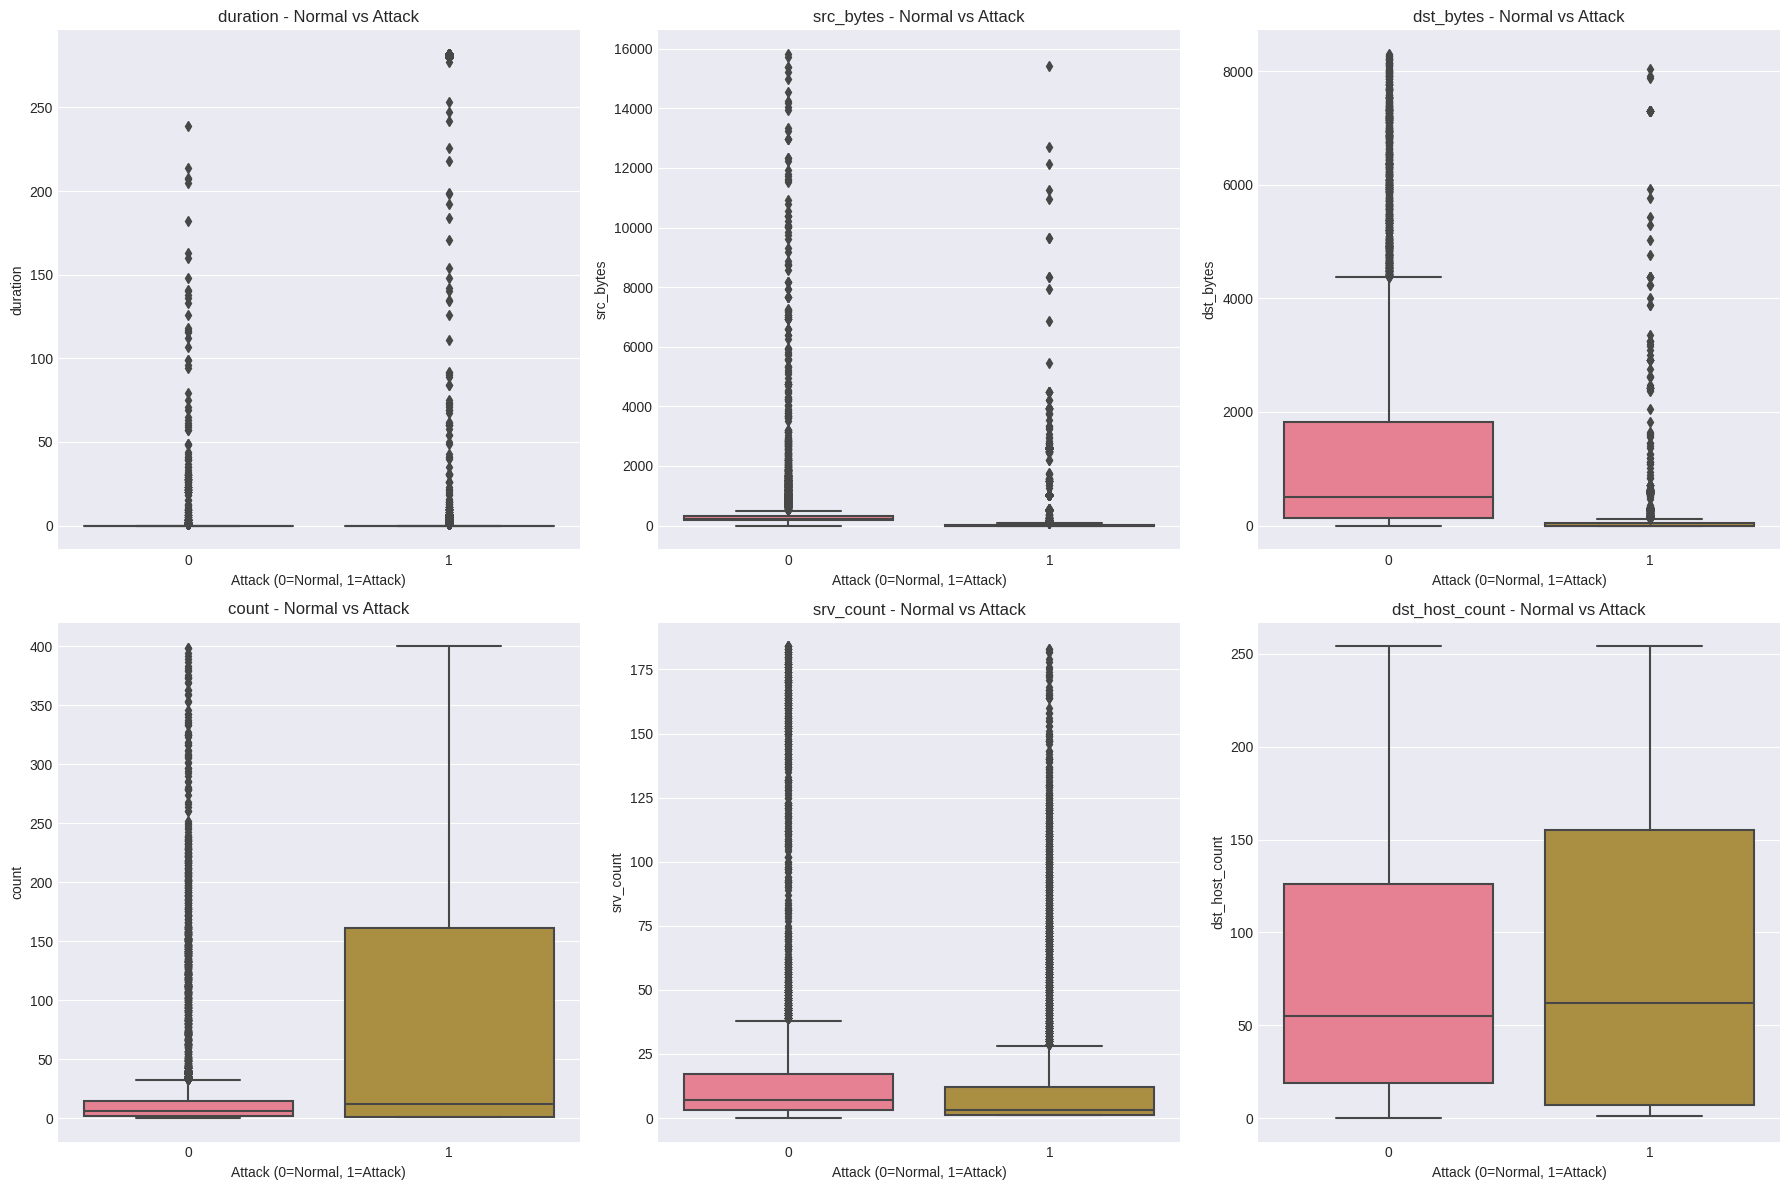

In [19]:
# Cell 13: Boxplots for Key Features (Normal vs Attack)
key_features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count', 'dst_host_count']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    # Use log scale for better visualization if needed
    data = train_df[train_df[feature] < train_df[feature].quantile(0.95)]  # Remove outliers for better view
    
    sns.boxplot(x='attack', y=feature, data=data, ax=axes[idx])
    axes[idx].set_title(f'{feature} - Normal vs Attack')
    axes[idx].set_xlabel('Attack (0=Normal, 1=Attack)')
    axes[idx].set_ylabel(feature)

plt.tight_layout()
plt.show()

Protocol Type vs Attack (%):
attack                 0          1
protocol_type                      
icmp            8.916587  91.083413
tcp            41.536017  58.463983
udp            67.760397  32.239603


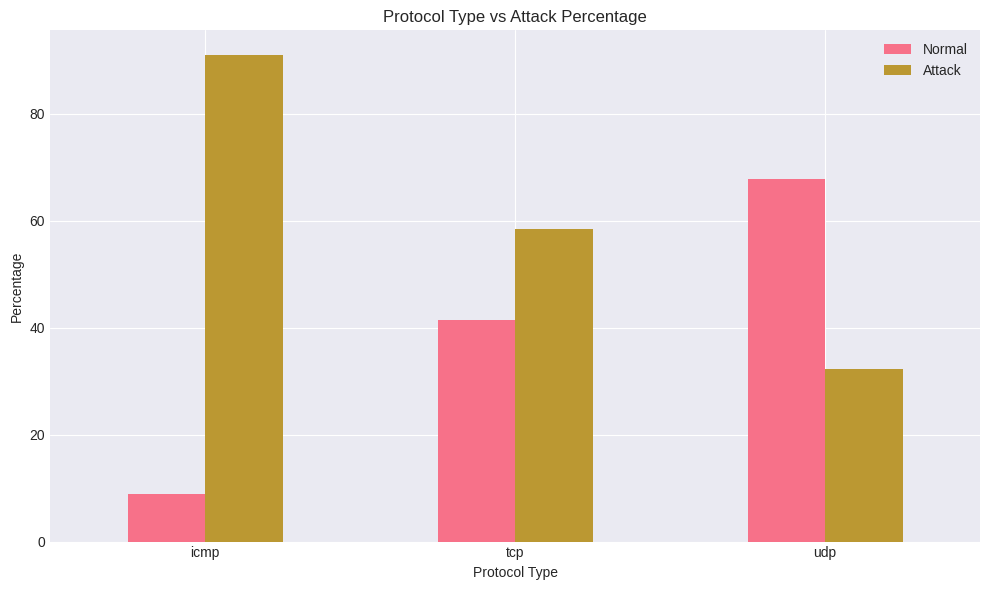

In [20]:
# Cell 14: Protocol Type vs Attack
protocol_attack = pd.crosstab(train_df['protocol_type'], train_df['attack'], normalize='index') * 100

print("Protocol Type vs Attack (%):")
print(protocol_attack)

# Visualize
protocol_attack.plot(kind='bar', figsize=(10, 6))
plt.title('Protocol Type vs Attack Percentage')
plt.xlabel('Protocol Type')
plt.ylabel('Percentage')
plt.legend(['Normal', 'Attack'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Top 10 Services vs Attack (%):
attack            0          1
service                       
http      84.973895  15.026105
private   17.846669  82.153331
telnet     2.706027  97.293973
pop_3      0.785083  99.214917
smtp      66.167024  33.832976
domain_u  99.776286   0.223714
ftp_data  37.602820  62.397180
other      7.756563  92.243437
ecr_i      6.382979  93.617021
ftp        6.936416  93.063584


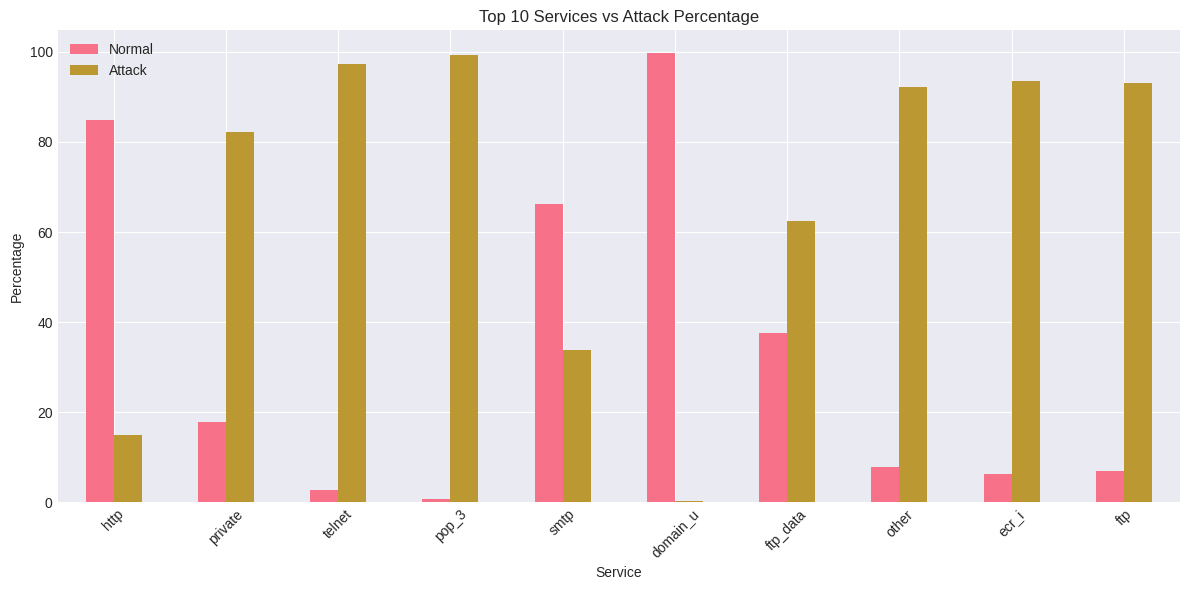

In [21]:
# Cell 15: Service vs Attack (Top 10 services)
top_services = train_df['service'].value_counts().head(10).index
service_attack = pd.crosstab(train_df['service'], train_df['attack'], normalize='index') * 100
service_attack_top = service_attack.loc[top_services]

print("Top 10 Services vs Attack (%):")
print(service_attack_top)

# Visualize
service_attack_top.plot(kind='bar', figsize=(12, 6))
plt.title('Top 10 Services vs Attack Percentage')
plt.xlabel('Service')
plt.ylabel('Percentage')
plt.legend(['Normal', 'Attack'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Flag vs Attack (%):
attack          0           1
flag                         
OTH      0.000000  100.000000
REJ      0.883117   99.116883
RSTO     0.258732   99.741268
RSTOS0  50.000000   50.000000
RSTR     6.576981   93.423019
S0       0.000000  100.000000
S1      52.380952   47.619048
S2      53.333333   46.666667
S3       1.606426   98.393574
SF      64.584874   35.415126
SH       0.000000  100.000000


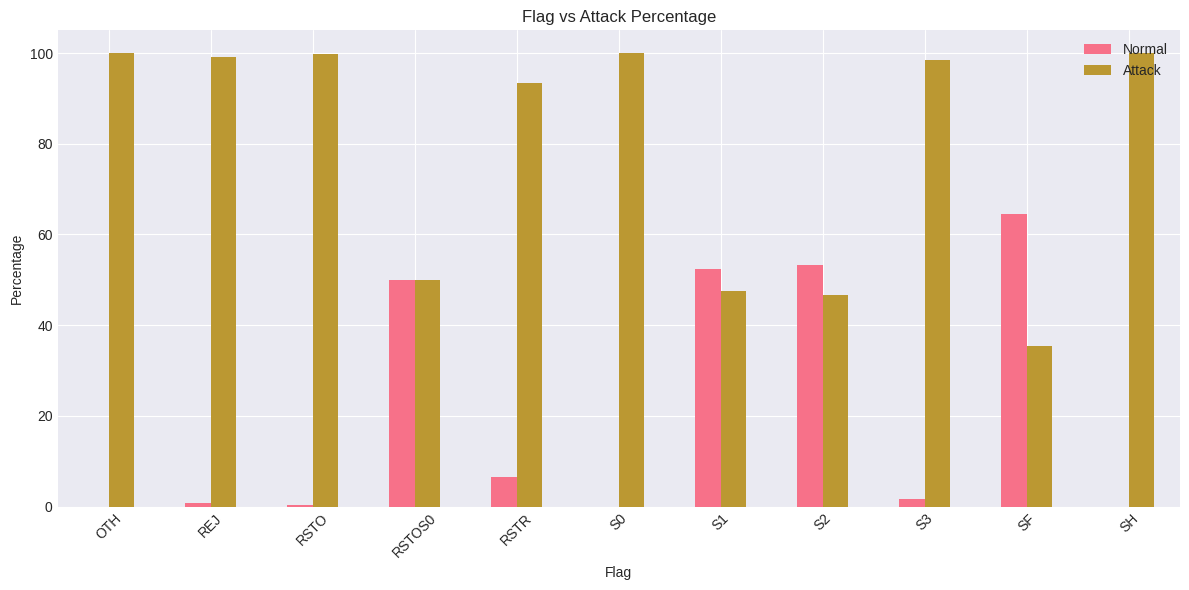

In [22]:
# Cell 16: Flag vs Attack
flag_attack = pd.crosstab(train_df['flag'], train_df['attack'], normalize='index') * 100

print("Flag vs Attack (%):")
print(flag_attack)

# Visualize
flag_attack.plot(kind='bar', figsize=(12, 6))
plt.title('Flag vs Attack Percentage')
plt.xlabel('Flag')
plt.ylabel('Percentage')
plt.legend(['Normal', 'Attack'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top 10 Features with Largest Mean Difference between Normal and Attack:
src_bytes                 13816.500891
dst_bytes                  3705.110341
duration                    301.788322
dst_host_srv_count          133.940354
count                        72.989984
dst_host_count               66.801499
srv_count                    17.034487
logged_in                     0.552790
dst_host_same_srv_rate        0.506367
same_srv_rate                 0.425358
dtype: float64


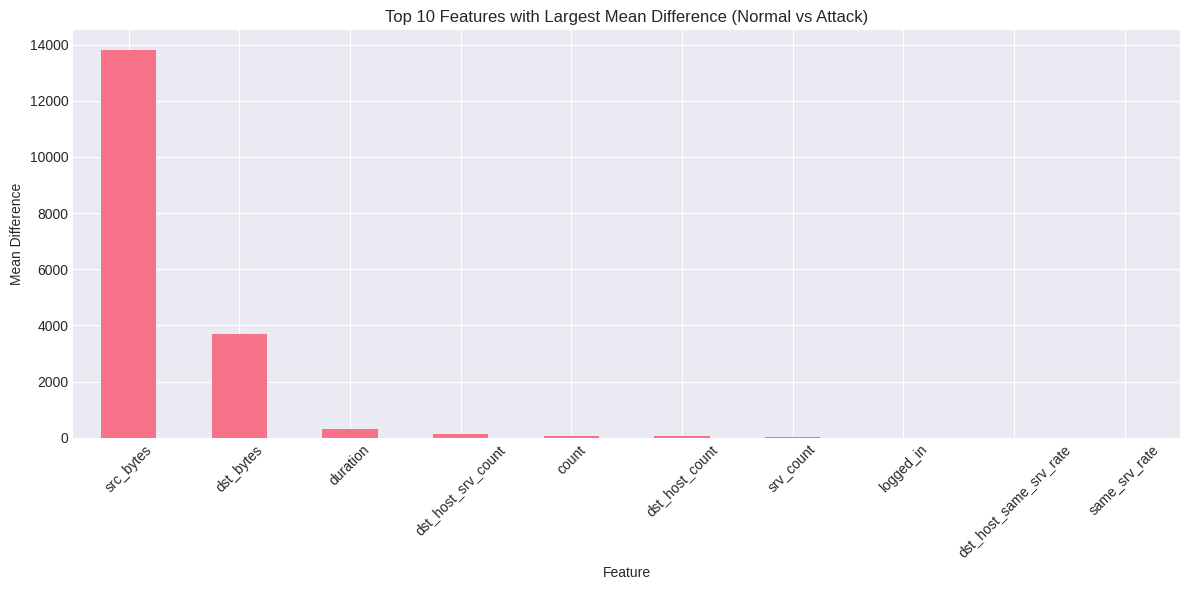

In [23]:
# Cell 17: Feature Importance - Mean Values Comparison
# Compare mean values for normal vs attack
normal_mean = train_df[train_df['attack'] == 0][numerical_cols].mean()
attack_mean = train_df[train_df['attack'] == 1][numerical_cols].mean()

diff_mean = abs(normal_mean - attack_mean)
diff_mean_sorted = diff_mean.sort_values(ascending=False)

print("Top 10 Features with Largest Mean Difference between Normal and Attack:")
print(diff_mean_sorted.head(10))

# Visualize
plt.figure(figsize=(12, 6))
diff_mean_sorted.head(10).plot(kind='bar')
plt.title('Top 10 Features with Largest Mean Difference (Normal vs Attack)')
plt.xlabel('Feature')
plt.ylabel('Mean Difference')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 18: Check for Imbalanced Classes - SMOTE Preparation
from sklearn.utils import resample

# Separate majority and minority classes
normal = train_df[train_df['attack'] == 0]
attack = train_df[train_df['attack'] == 1]

print(f"Normal samples: {len(normal)}")
print(f"Attack samples: {len(attack)}")
print(f"Imbalance ratio: {len(normal)/len(attack):.2f}:1")

# Check if class balancing is needed
if len(normal) > len(attack) * 1.5:
    print("\nDataset is imbalanced. Consider using SMOTE or undersampling.")
else:
    print("\nDataset is relatively balanced.")

Normal samples: 9711
Attack samples: 12833
Imbalance ratio: 0.76:1

✅ Dataset is relatively balanced.


In [ ]:
# Cell 19: Summary Statistics and Key Findings
print("="*50)
print("EDA SUMMARY - KEY FINDINGS")
print("="*50)

print(f"\n1. Dataset Size:")
print(f"   Training: {train_df.shape[0]} samples, {train_df.shape[1]} features")
print(f"   Test: {test_df.shape[0]} samples, {test_df.shape[1]} features")

print(f"\n2. Class Distribution:")
print(f"   Training - Normal: {train_normal_pct:.1f}%, Attack: {train_attack_pct:.1f}%")
print(f"   Test - Normal: {test_normal_pct:.1f}%, Attack: {test_attack_pct:.1f}%")

print(f"\n3. Attack Categories (Training):")
for category, count in train_df[train_df['label'] != 'normal']['attack_category'].value_counts().items():
    print(f"   {category}: {count} samples")

print(f"\n4. Missing Values:")
print(f"   Both training and test sets have 0 missing values")

print(f"\n5. Data Types:")
print(f"   {len(numerical_cols)} numerical features")
print(f"   {len(categorical_cols)} categorical features")

print(f"\n6. Most Discriminative Features (by mean difference):")
for feature, diff in diff_mean_sorted.head(5).items():
    print(f"   {feature}: {diff:.2f}")

print("\n7. Key Observations:")
print("   - Dataset is moderately imbalanced")
print("   - DoS attacks are most common")
print("   - TCP is the most common protocol")
print("   - Some features like 'src_bytes' have extreme outliers")
print("   - Multiple attack types are present across all categories")

EDA SUMMARY - KEY FINDINGS

1. Dataset Size:
   Training: 22544 samples, 45 features
   Test: 22544 samples, 45 features

2. Class Distribution:
   Training - Normal: 43.1%, Attack: 56.9%
   Test - Normal: 43.1%, Attack: 56.9%

3. Attack Categories (Training):
   DoS: 5741 samples
   Other: 3752 samples
   R2L: 2197 samples
   Probing: 1106 samples
   U2R: 37 samples

4. Missing Values:
   Both training and test sets have 0 missing values ✅

5. Data Types:
   38 numerical features
   3 categorical features

6. Most Discriminative Features (by mean difference):
   src_bytes: 13816.50
   dst_bytes: 3705.11
   duration: 301.79
   dst_host_srv_count: 133.94
   count: 72.99

7. Key Observations:
   - Dataset is moderately imbalanced
   - DoS attacks are most common
   - TCP is the most common protocol
   - Some features like 'src_bytes' have extreme outliers
   - Multiple attack types are present across all categories


In [26]:
# Cell 20: Save Cleaned Data for Next Steps
# This will be used for feature engineering and model building

# Save a copy of the data
train_df.to_csv('train_cleaned.csv', index=False)
test_df.to_csv('test_cleaned.csv', index=False)

print("Cleaned data saved successfully!")
print("\nNext steps:")
print("1. Feature Engineering (create new features)")
print("2. Feature Selection (reduce dimensionality)")
print("3. Data Preprocessing (scaling, encoding)")
print("4. Model Building and Training")

Cleaned data saved successfully!

Next steps:
1. Feature Engineering (create new features)
2. Feature Selection (reduce dimensionality)
3. Data Preprocessing (scaling, encoding)
4. Model Building and Training
